# 08 — Training Model Klasifikasi Citra Awan

Notebook ini digunakan untuk melatih model klasifikasi jenis awan menggunakan
PyTorch dan arsitektur ResNet18 dari library `timm`.

Notebook membaca konfigurasi yang telah dihasilkan oleh:

- `05_preprocessing_augmentasi.ipynb`
- `06_dataloader.ipynb`
- `07_persiapan_model.ipynb`

Tahapan training terdiri atas:

1. Memuat konfigurasi DataLoader dan model.
2. Memuat transform training dan validation.
3. Membentuk kembali objek Dataset dan DataLoader.
4. Menghitung bobot kelas dari training split.
5. Melatih classifier dengan backbone dibekukan.
6. Membuka seluruh backbone untuk fine-tuning.
7. Menggunakan validation loss untuk pemilihan model.
8. Menerapkan learning-rate scheduler dan early stopping.
9. Menyimpan checkpoint terbaik dan checkpoint terakhir.
10. Menyimpan riwayat training dan kurva pembelajaran.

Data test tidak dibaca atau digunakan dalam notebook ini. Test dataset tetap
disimpan untuk evaluasi akhir pada notebook berikutnya.

## Mengimpor Library

Library yang digunakan mencakup PyTorch, timm, Albumentations, ImageFolder,
TensorBoard, visualisasi, dan pengelolaan metadata.

Notebook tidak mendefinisikan ulang preprocessing maupun augmentasi karena
pipeline tersebut dibaca dari file JSON hasil notebook 05.

In [1]:
from pathlib import Path
from datetime import datetime
from contextlib import nullcontext

import json
import random
import re
import sys
import time

try:
    import albumentations as A
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import torch
    import torch.nn as nn
    import timm

    from albumentations.pytorch import ToTensorV2
    from IPython.display import display
    from PIL import Image
    from torch.optim import AdamW
    from torch.optim.lr_scheduler import ReduceLROnPlateau
    from torch.utils.data import DataLoader
    from torch.utils.tensorboard import SummaryWriter
    from torchvision.datasets import ImageFolder
    from tqdm.auto import tqdm

except ImportError as exc:
    raise ImportError(
        "Dependency training belum lengkap.\n\n"
        "Aktifkan .venv, kemudian jalankan melalui terminal VS Code:\n\n"
        r".\.venv\Scripts\python.exe -m pip install -r requirements.txt"
    ) from exc


pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)


print(f"Python          : {sys.version.split()[0]}")
print(f"NumPy           : {np.__version__}")
print(f"Pandas          : {pd.__version__}")
print(f"PyTorch         : {torch.__version__}")
print(f"timm            : {timm.__version__}")
print(f"Albumentations  : {A.__version__}")
print(f"CUDA tersedia   : {torch.cuda.is_available()}")

Python          : 3.11.9
NumPy           : 2.4.6
Pandas          : 3.0.5
PyTorch         : 2.13.0+cpu
timm            : 1.0.28
Albumentations  : 2.0.8
CUDA tersedia   : False


## Menentukan Lokasi Project

Lokasi project ditentukan secara dinamis agar notebook dapat dijalankan dari
folder utama project maupun dari folder `notebooks`.

Notebook tidak menggunakan path absolut Docker `/app`.

In [2]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR


DATASET_DIR = PROJECT_DIR / "dataset"
SOURCE_DIR = DATASET_DIR / "source"
PROCESSED_DIR = DATASET_DIR / "processed"

MODELS_DIR = PROJECT_DIR / "models"
LOGS_DIR = PROJECT_DIR / "logs"

TRAIN_DIR = SOURCE_DIR / "train"
VAL_DIR = SOURCE_DIR / "val"


DATALOADER_CONFIG_PATH = (
    PROCESSED_DIR
    / "dataloader_config.json"
)

MODEL_CONFIG_PATH = (
    PROCESSED_DIR
    / "model_config.json"
)

TRAIN_TRANSFORM_PATH = (
    PROCESSED_DIR
    / "train_transform.json"
)

EVAL_TRANSFORM_PATH = (
    PROCESSED_DIR
    / "eval_transform.json"
)


path_table = pd.DataFrame({
    "Nama": [
        "PROJECT_DIR",
        "TRAIN_DIR",
        "VAL_DIR",
        "DATALOADER_CONFIG_PATH",
        "MODEL_CONFIG_PATH",
        "TRAIN_TRANSFORM_PATH",
        "EVAL_TRANSFORM_PATH",
    ],
    "Path": [
        PROJECT_DIR,
        TRAIN_DIR,
        VAL_DIR,
        DATALOADER_CONFIG_PATH,
        MODEL_CONFIG_PATH,
        TRAIN_TRANSFORM_PATH,
        EVAL_TRANSFORM_PATH,
    ],
})

path_table["Ada"] = (
    path_table["Path"]
    .map(Path.exists)
)

display(path_table)

,Nama,Path,Ada
0,PROJECT_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification,True
1,TRAIN_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\train,True
2,VAL_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\val,True
3,DATALOADER_CONFIG_PATH,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed\dataloader_config.json,True
4,MODEL_CONFIG_PATH,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed\model_config.json,True
5,TRAIN_TRANSFORM_PATH,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed\train_transform.json,True
6,EVAL_TRANSFORM_PATH,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed\eval_transform.json,True


## Memeriksa Prasyarat

Training hanya dapat dijalankan setelah notebook 05, 06, dan 07 selesai.

Pemeriksaan dilakukan terhadap folder train, folder validation, konfigurasi
DataLoader, konfigurasi model, serta transform training dan validation.

Folder test tidak diperiksa karena tidak digunakan pada tahap training.

In [3]:
required_directories = [
    PROJECT_DIR,
    DATASET_DIR,
    SOURCE_DIR,
    PROCESSED_DIR,
    MODELS_DIR,
    LOGS_DIR,
    TRAIN_DIR,
    VAL_DIR,
]

required_files = [
    DATALOADER_CONFIG_PATH,
    MODEL_CONFIG_PATH,
    TRAIN_TRANSFORM_PATH,
    EVAL_TRANSFORM_PATH,
]


missing_directories = [
    path
    for path in required_directories
    if not path.is_dir()
]

missing_files = [
    path
    for path in required_files
    if not path.is_file()
]


if missing_directories:
    formatted_paths = "\n".join(
        f"- {path}"
        for path in missing_directories
    )

    raise FileNotFoundError(
        "Folder prasyarat belum tersedia:\n"
        f"{formatted_paths}"
    )


if missing_files:
    formatted_paths = "\n".join(
        f"- {path}"
        for path in missing_files
    )

    raise FileNotFoundError(
        "Artefak tahap sebelumnya belum tersedia:\n"
        f"{formatted_paths}\n\n"
        "Jalankan notebook 05, 06, dan 07 secara berurutan."
    )


print("Seluruh prasyarat training tersedia.")
print("Data test tidak diperiksa dan tidak digunakan.")

Seluruh prasyarat training tersedia.
Data test tidak diperiksa dan tidak digunakan.


## Membaca Konfigurasi Tahap Sebelumnya

Notebook membaca `dataloader_config.json` dan `model_config.json`.

Dengan pendekatan ini, jumlah kelas, nama model, ukuran input, ukuran batch,
seed, dropout, dan label smoothing tidak ditulis ulang secara manual.

In [4]:
with DATALOADER_CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    dataloader_config = json.load(file)


with MODEL_CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    model_config = json.load(file)


print("Konfigurasi DataLoader dan model berhasil dibaca.")

Konfigurasi DataLoader dan model berhasil dibaca.


## Memvalidasi Konfigurasi Model

Konfigurasi model harus memuat nama model, jumlah kelas, pemetaan kelas,
ukuran input, dropout, dan konfigurasi loss.

In [5]:
required_model_keys = {
    "model_name",
    "num_classes",
    "class_to_idx",
    "input_shape",
    "dropout_rate",
    "loss",
}


missing_model_keys = (
    required_model_keys
    - set(model_config.keys())
)


if missing_model_keys:
    raise KeyError(
        "model_config.json belum lengkap. "
        "Kunci yang hilang: "
        f"{sorted(missing_model_keys)}"
    )


MODEL_NAME = str(
    model_config["model_name"]
)

NUM_CLASSES = int(
    model_config["num_classes"]
)

CLASS_TO_IDX = {
    str(class_name): int(class_idx)
    for class_name, class_idx
    in model_config["class_to_idx"].items()
}

IDX_TO_CLASS = {
    class_idx: class_name
    for class_name, class_idx
    in CLASS_TO_IDX.items()
}


INPUT_CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH = map(
    int,
    model_config["input_shape"],
)


DROPOUT_RATE = float(
    model_config.get(
        "dropout_rate",
        0.0,
    )
)


LABEL_SMOOTHING = float(
    model_config
    .get("loss", {})
    .get("label_smoothing", 0.0)
)


SEED = int(
    dataloader_config.get(
        "random_seed",
        model_config.get("seed", 42),
    )
)

BATCH_SIZE = int(
    dataloader_config.get(
        "batch_size",
        32,
    )
)

NUM_WORKERS = int(
    dataloader_config.get(
        "num_workers",
        0,
    )
)

DROP_LAST = bool(
    dataloader_config.get(
        "drop_last",
        False,
    )
)

In [6]:
if NUM_CLASSES != len(CLASS_TO_IDX):
    raise ValueError(
        "Jumlah kelas tidak konsisten "
        "dengan class_to_idx."
    )


expected_class_indices = list(
    range(NUM_CLASSES)
)

observed_class_indices = sorted(
    CLASS_TO_IDX.values()
)


if observed_class_indices != expected_class_indices:
    raise ValueError(
        "Indeks kelas harus berurutan mulai dari 0.\n"
        f"Diharapkan: {expected_class_indices}\n"
        f"Ditemukan : {observed_class_indices}"
    )


configuration_table = pd.DataFrame({
    "Parameter": [
        "Model",
        "Jumlah kelas",
        "Input shape",
        "Batch size",
        "Num workers",
        "Seed",
        "Dropout",
        "Label smoothing",
    ],
    "Nilai": [
        MODEL_NAME,
        NUM_CLASSES,
        [
            INPUT_CHANNELS,
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
        ],
        BATCH_SIZE,
        NUM_WORKERS,
        SEED,
        DROPOUT_RATE,
        LABEL_SMOOTHING,
    ],
})


display(configuration_table)

,Parameter,Nilai
0,Model,resnet18
1,Jumlah kelas,7
2,Input shape,"[3, 224, 224]"
3,Batch size,32
4,Num workers,0
5,Seed,42
6,Dropout,0.2
7,Label smoothing,0.1


## Pemetaan Kelas

Pemetaan kelas berasal dari `model_config.json`. Notebook tidak menentukan
nama maupun jumlah kelas secara manual.

In [7]:
class_mapping_table = pd.DataFrame({
    "class_id": list(IDX_TO_CLASS.keys()),
    "class_name": list(IDX_TO_CLASS.values()),
}).sort_values(
    "class_id"
).reset_index(
    drop=True
)


display(class_mapping_table)

print(f"Jumlah kelas: {NUM_CLASSES}")

,class_id,class_name
0,0,1_cumulus
1,1,2_altocumulus
2,2,3_cirrus
3,3,4_clearsky
4,4,5_stratocumulus
5,5,6_cumulonimbus
6,6,7_mixed


Jumlah kelas: 7


## Reproduksibilitas dan Perangkat Komputasi

Seed yang digunakan mengikuti konfigurasi DataLoader.

Urutan pemilihan perangkat:

1. CUDA GPU.
2. Apple MPS.
3. CPU.

Mixed precision hanya diaktifkan ketika CUDA tersedia.

In [8]:
def seed_everything(
    seed: int,
) -> None:
    """
    Menetapkan seed Python, NumPy, dan PyTorch.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


seed_everything(SEED)


if torch.cuda.is_available():
    DEVICE = torch.device("cuda")

elif (
    hasattr(torch.backends, "mps")
    and torch.backends.mps.is_available()
):
    DEVICE = torch.device("mps")

else:
    DEVICE = torch.device("cpu")


PIN_MEMORY = DEVICE.type == "cuda"
NON_BLOCKING = DEVICE.type == "cuda"
PERSISTENT_WORKERS = NUM_WORKERS > 0
AMP_ENABLED = DEVICE.type == "cuda"


device_table = pd.DataFrame({
    "Parameter": [
        "Seed",
        "Device",
        "CUDA tersedia",
        "Mixed precision",
        "Pin memory",
        "Persistent workers",
    ],
    "Nilai": [
        SEED,
        str(DEVICE),
        torch.cuda.is_available(),
        AMP_ENABLED,
        PIN_MEMORY,
        PERSISTENT_WORKERS,
    ],
})


display(device_table)

,Parameter,Nilai
0,Seed,42
1,Device,cpu
2,CUDA tersedia,False
3,Mixed precision,False
4,Pin memory,False
5,Persistent workers,False


## Konfigurasi Training

Training dibagi menjadi dua fase.

### Fase 1 — Warm-up classifier

Backbone ResNet18 dibekukan. Hanya classification head yang dilatih dengan
learning rate lebih besar.

### Fase 2 — Fine-tuning

Seluruh parameter model dibuka kembali dan dilatih menggunakan learning rate
yang lebih kecil.

Jumlah epoch merupakan batas maksimum. Early stopping dapat menghentikan
training lebih awal apabila validation loss tidak membaik.

In [9]:
WARMUP_EPOCHS = 5
FINETUNE_EPOCHS = 20

WARMUP_LEARNING_RATE = 1e-3
FINETUNE_LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

EARLY_STOPPING_PATIENCE = 5

SCHEDULER_PATIENCE = 2
SCHEDULER_FACTOR = 0.5
MIN_LEARNING_RATE = 1e-7

GRADIENT_CLIP_NORM = 1.0

USE_CLASS_WEIGHTS = True

In [10]:
RUN_ID = (
    datetime.now()
    .astimezone()
    .strftime("%Y%m%d_%H%M%S")
)


SAFE_MODEL_NAME = re.sub(
    r"[^A-Za-z0-9_.-]+",
    "_",
    MODEL_NAME,
)


RUN_LOG_DIR = (
    LOGS_DIR
    / f"{SAFE_MODEL_NAME}_{RUN_ID}"
)

TENSORBOARD_DIR = (
    RUN_LOG_DIR
    / "tensorboard"
)


RUN_LOG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


BEST_CHECKPOINT_PATH = (
    MODELS_DIR
    / f"{SAFE_MODEL_NAME}_gcd_best.pth"
)

LAST_CHECKPOINT_PATH = (
    MODELS_DIR
    / f"{SAFE_MODEL_NAME}_gcd_last.pth"
)

HISTORY_PATH = (
    RUN_LOG_DIR
    / "training_history.csv"
)

TRAINING_CONFIG_PATH = (
    RUN_LOG_DIR
    / "training_config.json"
)

CURVE_PATH = (
    RUN_LOG_DIR
    / "learning_curves.png"
)

In [11]:
training_hyperparameter_table = pd.DataFrame({
    "Parameter": [
        "Warm-up epochs",
        "Fine-tuning epochs",
        "Warm-up learning rate",
        "Fine-tuning learning rate",
        "Weight decay",
        "Early stopping patience",
        "Scheduler patience",
        "Scheduler factor",
        "Gradient clipping",
        "Class weights",
    ],
    "Nilai": [
        WARMUP_EPOCHS,
        FINETUNE_EPOCHS,
        WARMUP_LEARNING_RATE,
        FINETUNE_LEARNING_RATE,
        WEIGHT_DECAY,
        EARLY_STOPPING_PATIENCE,
        SCHEDULER_PATIENCE,
        SCHEDULER_FACTOR,
        GRADIENT_CLIP_NORM,
        USE_CLASS_WEIGHTS,
    ],
})


display(training_hyperparameter_table)

print(
    "Folder log training:\n"
    f"{RUN_LOG_DIR.relative_to(PROJECT_DIR)}"
)

,Parameter,Nilai
0,Warm-up epochs,5
1,Fine-tuning epochs,20
2,Warm-up learning rate,0.001
3,Fine-tuning learning rate,0.0001
4,Weight decay,0.0001
5,Early stopping patience,5
6,Scheduler patience,2
7,Scheduler factor,0.5
8,Gradient clipping,1.0
9,Class weights,True


Folder log training:
logs\resnet18_20260825_233127


## Memuat Pipeline Transform

Pipeline training dan evaluasi dimuat dari file JSON yang dihasilkan notebook 05.

- Training menggunakan augmentasi stokastik.
- Validation menggunakan preprocessing deterministik.
- Definisi transform tidak ditulis kembali.

In [12]:
train_transform_pipeline = A.load(
    str(TRAIN_TRANSFORM_PATH),
    data_format="json",
)

eval_transform_pipeline = A.load(
    str(EVAL_TRANSFORM_PATH),
    data_format="json",
)


if hasattr(
    train_transform_pipeline,
    "set_random_seed",
):
    train_transform_pipeline.set_random_seed(
        SEED
    )


if hasattr(
    eval_transform_pipeline,
    "set_random_seed",
):
    eval_transform_pipeline.set_random_seed(
        SEED
    )


print("Pipeline training:")
print(train_transform_pipeline)

print("\nPipeline validation:")
print(eval_transform_pipeline)

Pipeline training:
Compose([
  Resize(p=1.0, area_for_downscale=None, height=224, interpolation=1, mask_interpolation=0, width=224),
  HorizontalFlip(p=0.5),
  Affine(p=0.5, balanced_scale=False, border_mode=4, fill=0.0, fill_mask=0.0, fit_output=False, interpolation=1, keep_ratio=False, mask_interpolation=0, rotate=(-10.0, 10.0), rotate_method='largest_box', scale={'x': (0.9, 1.1), 'y': (0.9, 1.1)}, shear={'x': (-3.0, 3.0), 'y': (-3.0, 3.0)}, translate_percent={'x': (-0.05, 0.05), 'y': (-0.05, 0.05)}, translate_px=None),
  RandomBrightnessContrast(p=0.35, brightness_by_max=True, brightness_limit=(-0.15, 0.15), contrast_limit=(-0.15, 0.15), ensure_safe_range=False),
  GaussianBlur(p=0.1, blur_limit=(3, 5), sigma_limit=(0.5, 3.0)),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.485, 0.456, 0.406), normalization='standard', std=(0.229, 0.224, 0.225)),
  ToTensorV2(p=1.0, transpose_mask=False),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=Tru

## Adapter Albumentations untuk ImageFolder

`ImageFolder` membaca citra sebagai objek PIL, sedangkan Albumentations menerima
array NumPy.

Adapter berikut hanya melakukan konversi format. Adapter tidak membuat ulang
preprocessing atau augmentasi.

In [13]:
class AlbumentationsImageTransform:
    """
    Adapter citra PIL/NumPy menuju pipeline Albumentations.
    """

    def __init__(
        self,
        pipeline,
    ):
        self.pipeline = pipeline


    def __call__(
        self,
        image,
    ) -> torch.Tensor:
        if isinstance(image, Image.Image):
            image = np.asarray(
                image.convert("RGB")
            )

        else:
            image = np.asarray(image)


        transformed = self.pipeline(
            image=image
        )["image"]


        # Fallback jika pipeline tidak memiliki ToTensorV2.
        if isinstance(
            transformed,
            np.ndarray,
        ):
            transformed = torch.from_numpy(
                np.ascontiguousarray(
                    transformed.transpose(
                        2,
                        0,
                        1,
                    )
                )
            )

            if transformed.dtype == torch.uint8:
                transformed = (
                    transformed.float()
                    / 255.0
                )


        if not torch.is_tensor(transformed):
            raise TypeError(
                "Output transform harus berupa torch.Tensor."
            )


        return transformed.float()


train_transform = AlbumentationsImageTransform(
    train_transform_pipeline
)

eval_transform = AlbumentationsImageTransform(
    eval_transform_pipeline
)


print("Adapter transform berhasil dibuat.")

Adapter transform berhasil dibuat.


## Membentuk Dataset

Dataset dibentuk menggunakan `ImageFolder` karena folder source sudah memiliki
struktur:

dataset/source/
├── train/
│   └── nama_kelas/
└── val/
    └── nama_kelas/

Notebook tidak membentuk objek dataset test.

In [14]:
train_dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform,
)

val_dataset = ImageFolder(
    root=VAL_DIR,
    transform=eval_transform,
)


print(f"Jumlah citra training   : {len(train_dataset):,}")
print(f"Jumlah citra validation : {len(val_dataset):,}")
print(f"Jumlah kelas training   : {len(train_dataset.classes)}")
print(f"Jumlah kelas validation : {len(val_dataset.classes)}")

Jumlah citra training   : 7,874
Jumlah citra validation : 1,969
Jumlah kelas training   : 7
Jumlah kelas validation : 7


## Memvalidasi Kelas Dataset

Nama kelas pada folder train dan validation harus sama dengan pemetaan kelas
yang tersimpan pada `model_config.json`.

Pemeriksaan ini mencegah perubahan label secara tidak sengaja.

In [15]:
train_classes = set(
    train_dataset.classes
)

val_classes = set(
    val_dataset.classes
)

expected_classes = set(
    CLASS_TO_IDX.keys()
)


if train_classes != expected_classes:
    raise ValueError(
        "Folder kelas training tidak sesuai "
        "dengan model_config.json.\n"
        f"Diharapkan: {sorted(expected_classes)}\n"
        f"Ditemukan : {sorted(train_classes)}"
    )


if val_classes != expected_classes:
    raise ValueError(
        "Folder kelas validation tidak sesuai "
        "dengan model_config.json.\n"
        f"Diharapkan: {sorted(expected_classes)}\n"
        f"Ditemukan : {sorted(val_classes)}"
    )


print(
    "Nama kelas training dan validation "
    "sesuai dengan model_config.json."
)

Nama kelas training dan validation sesuai dengan model_config.json.


## Menyesuaikan Indeks Kelas

`ImageFolder` membuat indeks kelas berdasarkan urutan alfabet folder.

Indeks tersebut harus disesuaikan dengan `class_to_idx` dari notebook sebelumnya
agar label pada training tetap konsisten.

In [16]:
class TargetIndexRemapper:
    """
    Mengubah indeks kelas ImageFolder menjadi indeks
    pada model_config.json.
    """

    def __init__(
        self,
        imagefolder_classes,
        expected_mapping,
    ):
        self.mapping = {
            source_idx: expected_mapping[class_name]
            for source_idx, class_name
            in enumerate(imagefolder_classes)
        }


    def __call__(
        self,
        source_idx: int,
    ) -> int:
        return int(
            self.mapping[int(source_idx)]
        )

In [17]:
train_remapper = TargetIndexRemapper(
    imagefolder_classes=train_dataset.classes,
    expected_mapping=CLASS_TO_IDX,
)

val_remapper = TargetIndexRemapper(
    imagefolder_classes=val_dataset.classes,
    expected_mapping=CLASS_TO_IDX,
)


train_dataset.target_transform = (
    train_remapper
)

val_dataset.target_transform = (
    val_remapper
)


dataset_table = pd.DataFrame({
    "split": [
        "train",
        "val",
    ],
    "jumlah_citra": [
        len(train_dataset),
        len(val_dataset),
    ],
    "jumlah_kelas": [
        len(train_dataset.classes),
        len(val_dataset.classes),
    ],
})


display(dataset_table)

print("Dataset test tidak dibentuk.")

,split,jumlah_citra,jumlah_kelas
0,train,7874,7
1,val,1969,7


Dataset test tidak dibentuk.


## Menghitung Bobot Kelas

Bobot kelas dihitung hanya dari training split.

Kelas dengan jumlah citra lebih sedikit memperoleh bobot loss lebih besar.
Pendekatan ini membantu mengurangi dominasi kelas dengan jumlah sampel besar.

In [18]:
train_targets = np.array(
    [
        train_remapper(target)
        for target
        in train_dataset.targets
    ],
    dtype=np.int64,
)


class_counts = np.bincount(
    train_targets,
    minlength=NUM_CLASSES,
)


if np.any(class_counts == 0):
    empty_class_ids = (
        np.where(class_counts == 0)[0]
        .tolist()
    )

    raise ValueError(
        "Kelas training kosong ditemukan: "
        f"{empty_class_ids}"
    )


class_weights_np = (
    len(train_targets)
    / (
        NUM_CLASSES
        * class_counts.astype(np.float64)
    )
)


if USE_CLASS_WEIGHTS:
    class_weights = torch.tensor(
        class_weights_np,
        dtype=torch.float32,
        device=DEVICE,
    )

else:
    class_weights = None

In [19]:
class_distribution_table = pd.DataFrame({
    "class_id": list(
        range(NUM_CLASSES)
    ),
    "class_name": [
        IDX_TO_CLASS[class_idx]
        for class_idx
        in range(NUM_CLASSES)
    ],
    "train_count": class_counts,
    "loss_weight": class_weights_np,
})


display(class_distribution_table)

,class_id,class_name,train_count,loss_weight
0,0,1_cumulus,620,1.814286
1,1,2_altocumulus,580,1.939409
2,2,3_cirrus,922,1.220019
3,3,4_clearsky,1596,0.704798
4,4,5_stratocumulus,1477,0.761582
5,5,6_cumulonimbus,2402,0.468300
6,6,7_mixed,277,4.060856


## Membentuk DataLoader

DataLoader hanya dibentuk untuk train dan validation.

Training menggunakan shuffle, sedangkan validation mempertahankan urutan data.
Seed generator dan worker digunakan untuk meningkatkan reproduksibilitas.

In [20]:
def seed_worker(
    worker_id: int,
) -> None:
    """
    Memberikan seed berbeda namun reproducible
    kepada setiap worker DataLoader.
    """
    worker_seed = (
        SEED + worker_id
    ) % (2**32)

    np.random.seed(worker_seed)
    random.seed(worker_seed)


def create_loader(
    dataset,
    shuffle: bool,
    seed: int,
) -> DataLoader:
    """
    Membentuk DataLoader menggunakan konfigurasi notebook 06.
    """
    generator = torch.Generator()
    generator.manual_seed(seed)


    return DataLoader(
        dataset=dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
        drop_last=DROP_LAST,
        worker_init_fn=seed_worker,
        generator=generator,
    )

In [21]:
train_loader = create_loader(
    dataset=train_dataset,
    shuffle=True,
    seed=SEED,
)

val_loader = create_loader(
    dataset=val_dataset,
    shuffle=False,
    seed=SEED,
)


print("DataLoader berhasil dibuat.")
print(f"Batch training   : {len(train_loader):,}")
print(f"Batch validation : {len(val_loader):,}")

DataLoader berhasil dibuat.
Batch training   : 247
Batch validation : 62


## Memeriksa Batch DataLoader

Pemeriksaan memastikan batch memiliki bentuk `[batch, channel, height, width]`,
tidak mengandung NaN, dan label berada dalam rentang kelas.

In [22]:
train_images, train_labels = next(
    iter(train_loader)
)

val_images, val_labels = next(
    iter(val_loader)
)


if train_images.ndim != 4:
    raise ValueError(
        "Batch training harus memiliki empat dimensi."
    )


if val_images.ndim != 4:
    raise ValueError(
        "Batch validation harus memiliki empat dimensi."
    )


if train_images.shape[1] != INPUT_CHANNELS:
    raise ValueError(
        "Jumlah channel training tidak sesuai konfigurasi model."
    )


if val_images.shape[1] != INPUT_CHANNELS:
    raise ValueError(
        "Jumlah channel validation tidak sesuai konfigurasi model."
    )


if not torch.isfinite(train_images).all():
    raise ValueError(
        "Batch training mengandung NaN atau infinity."
    )


if not torch.isfinite(val_images).all():
    raise ValueError(
        "Batch validation mengandung NaN atau infinity."
    )


if (
    train_labels.min().item() < 0
    or train_labels.max().item() >= NUM_CLASSES
):
    raise ValueError(
        "Label training berada di luar rentang kelas."
    )


if (
    val_labels.min().item() < 0
    or val_labels.max().item() >= NUM_CLASSES
):
    raise ValueError(
        "Label validation berada di luar rentang kelas."
    )

In [23]:
batch_table = pd.DataFrame({
    "Komponen": [
        "Training images",
        "Training labels",
        "Validation images",
        "Validation labels",
    ],
    "Bentuk": [
        tuple(train_images.shape),
        tuple(train_labels.shape),
        tuple(val_images.shape),
        tuple(val_labels.shape),
    ],
    "Dtype": [
        str(train_images.dtype),
        str(train_labels.dtype),
        str(val_images.dtype),
        str(val_labels.dtype),
    ],
})


display(batch_table)

print("Pemeriksaan batch berhasil.")

,Komponen,Bentuk,Dtype
0,Training images,"(32, 3, 224, 224)",torch.float32
1,Training labels,"(32,)",torch.int64
2,Validation images,"(32, 3, 224, 224)",torch.float32
3,Validation labels,"(32,)",torch.int64


Pemeriksaan batch berhasil.


## Membangun Model Training

Model dibangun kembali berdasarkan `model_config.json`.

Apabila notebook 07 berhasil memuat bobot pretrained, notebook training juga
menggunakan bobot pretrained yang sama. Pada fase awal, hanya classifier yang
dapat diperbarui.

In [24]:
PRETRAINED_FOR_TRAINING = bool(
    model_config.get(
        "pretrained_loaded",
        False,
    )
)


try:
    model = timm.create_model(
        MODEL_NAME,
        pretrained=PRETRAINED_FOR_TRAINING,
        num_classes=NUM_CLASSES,
        in_chans=INPUT_CHANNELS,
        drop_rate=DROPOUT_RATE,
    )

except Exception as exc:
    raise RuntimeError(
        "Model training gagal dibangun. "
        "Jika bobot pretrained pernah berhasil dimuat "
        "pada notebook 07, pastikan cache bobot masih tersedia."
    ) from exc

In [25]:
def set_classifier_only_trainable(
    model: nn.Module,
) -> None:
    """
    Membekukan seluruh model dan membuka classifier.
    """
    model.requires_grad_(False)

    classifier = model.get_classifier()
    classifier.requires_grad_(True)


def set_all_parameters_trainable(
    model: nn.Module,
) -> None:
    """
    Membuka seluruh parameter untuk fine-tuning.
    """
    model.requires_grad_(True)

In [26]:
set_classifier_only_trainable(
    model
)

model = model.to(
    DEVICE
)


TOTAL_PARAMETERS = sum(
    parameter.numel()
    for parameter
    in model.parameters()
)

TRAINABLE_WARMUP_PARAMETERS = sum(
    parameter.numel()
    for parameter
    in model.parameters()
    if parameter.requires_grad
)

FROZEN_WARMUP_PARAMETERS = (
    TOTAL_PARAMETERS
    - TRAINABLE_WARMUP_PARAMETERS
)


model_parameter_table = pd.DataFrame({
    "Jenis": [
        "Total parameter",
        "Trainable warm-up",
        "Frozen warm-up",
    ],
    "Jumlah": [
        TOTAL_PARAMETERS,
        TRAINABLE_WARMUP_PARAMETERS,
        FROZEN_WARMUP_PARAMETERS,
    ],
})


display(model_parameter_table)

print(f"Model                : {MODEL_NAME}")
print(f"Pretrained digunakan : {PRETRAINED_FOR_TRAINING}")
print(f"Device               : {DEVICE}")

,Jenis,Jumlah
0,Total parameter,11180103
1,Trainable warm-up,3591
2,Frozen warm-up,11176512


Model                : resnet18
Pretrained digunakan : True
Device               : cpu


## Loss dan Mixed Precision

`CrossEntropyLoss` menerima output logits dari model.

Konfigurasi loss menggunakan:

- class weighting dari training split;
- label smoothing dari notebook 07.

Mixed precision hanya digunakan pada CUDA.

In [27]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING,
)


try:
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=AMP_ENABLED,
    )

except (
    AttributeError,
    TypeError,
):
    scaler = torch.cuda.amp.GradScaler(
        enabled=AMP_ENABLED
    )


def autocast_context():
    """
    Mengaktifkan autocast hanya ketika CUDA digunakan.
    """
    if AMP_ENABLED:
        return torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
        )

    return nullcontext()


print(criterion)
print(f"Mixed precision aktif: {AMP_ENABLED}")

CrossEntropyLoss()
Mixed precision aktif: False


## Fungsi Training dan Validation Satu Epoch

Fungsi yang sama digunakan untuk training dan validation.

Ketika optimizer diberikan, fungsi menjalankan backpropagation. Ketika optimizer
tidak diberikan, fungsi hanya menjalankan validation.

Pada fase warm-up, layer BatchNorm dipertahankan dalam mode evaluasi agar
running mean dan running variance pada backbone tidak berubah.

In [28]:
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer=None,
    freeze_backbone: bool = False,
    description: str = "Epoch",
) -> dict:
    """
    Menjalankan satu epoch training atau validation.

    optimizer diberikan:
        mode training.

    optimizer=None:
        mode validation.
    """
    is_training = optimizer is not None


    if is_training:
        model.train()

        if freeze_backbone:
            for module in model.modules():
                if isinstance(
                    module,
                    nn.modules.batchnorm._BatchNorm,
                ):
                    module.eval()

    else:
        model.eval()


    running_loss = 0.0
    running_correct = 0
    running_samples = 0


    progress_bar = tqdm(
        loader,
        desc=description,
        leave=False,
    )


    for images, labels in progress_bar:
        images = images.to(
            DEVICE,
            non_blocking=NON_BLOCKING,
        )

        labels = labels.to(
            DEVICE,
            non_blocking=NON_BLOCKING,
        )


        if is_training:
            optimizer.zero_grad(
                set_to_none=True
            )


        with torch.set_grad_enabled(
            is_training
        ):
            with autocast_context():
                logits = model(images)

                loss = criterion(
                    logits,
                    labels,
                )


            if not torch.isfinite(loss):
                raise FloatingPointError(
                    "Loss tidak finite pada "
                    f"{description}: {loss.item()}"
                )


            if is_training:
                scaler.scale(
                    loss
                ).backward()

                scaler.unscale_(
                    optimizer
                )

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=GRADIENT_CLIP_NORM,
                )

                scaler.step(
                    optimizer
                )

                scaler.update()


        batch_size = labels.size(0)

        predictions = logits.argmax(
            dim=1
        )


        running_loss += (
            loss.detach().item()
            * batch_size
        )

        running_correct += (
            predictions
            .eq(labels)
            .sum()
            .item()
        )

        running_samples += batch_size


        progress_bar.set_postfix({
            "loss": (
                f"{running_loss / running_samples:.4f}"
            ),
            "accuracy": (
                f"{running_correct / running_samples:.4f}"
            ),
        })


    if running_samples == 0:
        raise RuntimeError(
            "DataLoader tidak menghasilkan sampel."
        )


    return {
        "loss": (
            running_loss
            / running_samples
        ),
        "accuracy": (
            running_correct
            / running_samples
        ),
        "samples": running_samples,
    }

## Membentuk Isi Checkpoint

Checkpoint menyimpan bobot model, optimizer, scheduler, fase training, epoch,
metrik validation, pemetaan kelas, dan ukuran input.

Checkpoint juga mencatat bahwa data test tidak digunakan.

In [29]:
def create_checkpoint_payload(
    model,
    optimizer,
    scheduler,
    phase: str,
    phase_epoch: int,
    global_epoch: int,
    metrics: dict,
) -> dict:
    """
    Membentuk dictionary checkpoint.
    """
    return {
        "saved_at": (
            datetime.now()
            .astimezone()
            .isoformat(timespec="seconds")
        ),
        "run_id": RUN_ID,
        "model_name": MODEL_NAME,
        "model_state_dict": (
            model.state_dict()
        ),
        "optimizer_state_dict": (
            optimizer.state_dict()
        ),
        "scheduler_state_dict": (
            scheduler.state_dict()
        ),
        "phase": phase,
        "phase_epoch": phase_epoch,
        "global_epoch": global_epoch,
        "metrics": metrics,
        "class_to_idx": CLASS_TO_IDX,
        "input_shape": [
            INPUT_CHANNELS,
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
        ],
        "dropout_rate": DROPOUT_RATE,
        "label_smoothing": LABEL_SMOOTHING,
        "pretrained_used": (
            PRETRAINED_FOR_TRAINING
        ),
        "test_data_used": False,
    }

In [30]:
def load_training_checkpoint(
    checkpoint_path: Path,
):
    """
    Memuat checkpoint pada beberapa versi PyTorch.
    """
    try:
        return torch.load(
            checkpoint_path,
            map_location=DEVICE,
            weights_only=False,
        )

    except TypeError:
        return torch.load(
            checkpoint_path,
            map_location=DEVICE,
        )

## Fungsi Training per Fase

Checkpoint terbaik ditentukan berdasarkan validation loss terendah.

Early stopping diterapkan secara terpisah pada setiap fase agar proses
fine-tuning tetap memperoleh kesempatan untuk memperbaiki model.

In [31]:
def fit_phase(
    phase_name: str,
    epochs: int,
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer,
    scheduler,
    writer,
    history: list,
    global_epoch: int,
    global_best_val_loss: float,
    freeze_backbone: bool,
):
    """
    Menjalankan satu fase training.
    """
    phase_best_val_loss = float("inf")
    epochs_without_improvement = 0


    for phase_epoch in range(
        1,
        epochs + 1,
    ):
        global_epoch += 1

        epoch_start = (
            time.perf_counter()
        )


        train_metrics = run_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            freeze_backbone=freeze_backbone,
            description=(
                f"{phase_name} train "
                f"{phase_epoch}/{epochs}"
            ),
        )


        val_metrics = run_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            optimizer=None,
            freeze_backbone=False,
            description=(
                f"{phase_name} val "
                f"{phase_epoch}/{epochs}"
            ),
        )


        scheduler.step(
            val_metrics["loss"]
        )


        learning_rate = float(
            optimizer
            .param_groups[0]["lr"]
        )


        elapsed_seconds = (
            time.perf_counter()
            - epoch_start
        )


        epoch_record = {
            "run_id": RUN_ID,
            "phase": phase_name,
            "phase_epoch": phase_epoch,
            "global_epoch": global_epoch,
            "train_loss": (
                train_metrics["loss"]
            ),
            "train_accuracy": (
                train_metrics["accuracy"]
            ),
            "val_loss": (
                val_metrics["loss"]
            ),
            "val_accuracy": (
                val_metrics["accuracy"]
            ),
            "learning_rate": learning_rate,
            "elapsed_seconds": elapsed_seconds,
        }


        history.append(
            epoch_record
        )


        writer.add_scalar(
            "loss/train",
            train_metrics["loss"],
            global_epoch,
        )

        writer.add_scalar(
            "loss/validation",
            val_metrics["loss"],
            global_epoch,
        )

        writer.add_scalar(
            "accuracy/train",
            train_metrics["accuracy"],
            global_epoch,
        )

        writer.add_scalar(
            "accuracy/validation",
            val_metrics["accuracy"],
            global_epoch,
        )

        writer.add_scalar(
            "learning_rate",
            learning_rate,
            global_epoch,
        )


        checkpoint = create_checkpoint_payload(
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            phase=phase_name,
            phase_epoch=phase_epoch,
            global_epoch=global_epoch,
            metrics=epoch_record,
        )


        torch.save(
            checkpoint,
            LAST_CHECKPOINT_PATH,
        )


        if (
            val_metrics["loss"]
            < global_best_val_loss
        ):
            global_best_val_loss = (
                val_metrics["loss"]
            )

            torch.save(
                checkpoint,
                BEST_CHECKPOINT_PATH,
            )

            best_marker = (
                " — checkpoint terbaik"
            )

        else:
            best_marker = ""


        if (
            val_metrics["loss"]
            < phase_best_val_loss
        ):
            phase_best_val_loss = (
                val_metrics["loss"]
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1


        print(
            f"[{phase_name}] "
            f"Epoch {phase_epoch:02d}/{epochs:02d} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"train_acc={train_metrics['accuracy']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"lr={learning_rate:.2e} | "
            f"waktu={elapsed_seconds:.1f}s"
            f"{best_marker}"
        )


        pd.DataFrame(
            history
        ).to_csv(
            HISTORY_PATH,
            index=False,
            encoding="utf-8",
        )


        if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                f"Early stopping pada fase {phase_name}. "
                "Validation loss tidak membaik selama "
                f"{EARLY_STOPPING_PATIENCE} epoch."
            )

            break


    return (
        global_epoch,
        global_best_val_loss,
    )

## Fase 1 — Warm-up Classifier

Pada fase ini, backbone ResNet18 dibekukan. Optimizer hanya menerima parameter
classifier yang memiliki `requires_grad=True`.

Tujuan warm-up adalah menyesuaikan classification head dengan kelas dataset
awan sebelum seluruh backbone dibuka.

In [32]:
history = []

global_epoch = 0

global_best_val_loss = float(
    "inf"
)


warmup_optimizer = AdamW(
    (
        parameter
        for parameter
        in model.parameters()
        if parameter.requires_grad
    ),
    lr=WARMUP_LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)


warmup_scheduler = ReduceLROnPlateau(
    warmup_optimizer,
    mode="min",
    factor=SCHEDULER_FACTOR,
    patience=SCHEDULER_PATIENCE,
    min_lr=MIN_LEARNING_RATE,
)


writer = SummaryWriter(
    log_dir=str(TENSORBOARD_DIR)
)


print("Memulai warm-up classifier.")

Memulai warm-up classifier.


In [33]:
try:
    (
        global_epoch,
        global_best_val_loss,
    ) = fit_phase(
        phase_name="warmup_classifier",
        epochs=WARMUP_EPOCHS,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=warmup_optimizer,
        scheduler=warmup_scheduler,
        writer=writer,
        history=history,
        global_epoch=global_epoch,
        global_best_val_loss=(
            global_best_val_loss
        ),
        freeze_backbone=True,
    )

finally:
    writer.flush()


print(
    "Warm-up selesai. "
    "Validation loss terbaik: "
    f"{global_best_val_loss:.6f}"
)

warmup_classifier train 1/5:   0%|          | 0/247 [00:00<?, ?it/s]

warmup_classifier val 1/5:   0%|          | 0/62 [00:00<?, ?it/s]

[warmup_classifier] Epoch 01/05 | train_loss=1.6705 | train_acc=0.5424 | val_loss=1.6030 | val_acc=0.6633 | lr=1.00e-03 | waktu=192.9s — checkpoint terbaik


warmup_classifier train 2/5:   0%|          | 0/247 [00:00<?, ?it/s]

warmup_classifier val 2/5:   0%|          | 0/62 [00:00<?, ?it/s]

...

warmup_classifier val 4/5:   0%|          | 0/62 [00:00<?, ?it/s]

[warmup_classifier] Epoch 04/05 | train_loss=1.2226 | train_acc=0.7231 | val_loss=1.3656 | val_acc=0.7598 | lr=1.00e-03 | waktu=188.8s — checkpoint terbaik


warmup_classifier train 5/5:   0%|          | 0/247 [00:00<?, ?it/s]

warmup_classifier val 5/5:   0%|          | 0/62 [00:00<?, ?it/s]

[warmup_classifier] Epoch 05/05 | train_loss=1.1971 | train_acc=0.7305 | val_loss=1.3363 | val_acc=0.7725 | lr=1.00e-03 | waktu=191.8s — checkpoint terbaik
Warm-up selesai. Validation loss terbaik: 1.336292


## Menyiapkan Fine-tuning

Checkpoint terbaik dari fase warm-up dimuat kembali.

Seluruh parameter model kemudian dibuka dan optimizer baru dibuat menggunakan
learning rate yang lebih kecil.

In [34]:
if not BEST_CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        "Checkpoint terbaik warm-up tidak ditemukan."
    )


warmup_best_checkpoint = (
    load_training_checkpoint(
        BEST_CHECKPOINT_PATH
    )
)


model.load_state_dict(
    warmup_best_checkpoint[
        "model_state_dict"
    ]
)


set_all_parameters_trainable(
    model
)


TRAINABLE_FINETUNE_PARAMETERS = sum(
    parameter.numel()
    for parameter
    in model.parameters()
    if parameter.requires_grad
)


print(
    "Parameter trainable fine-tuning: "
    f"{TRAINABLE_FINETUNE_PARAMETERS:,}"
)

Parameter trainable fine-tuning: 11,180,103


## Fase 2 — Fine-tuning Seluruh Model

Pada fase ini seluruh parameter model dapat diperbarui.

Learning rate dibuat lebih kecil daripada fase warm-up untuk mencegah perubahan
bobot pretrained yang terlalu besar.

In [35]:
finetune_optimizer = AdamW(
    model.parameters(),
    lr=FINETUNE_LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)


finetune_scheduler = ReduceLROnPlateau(
    finetune_optimizer,
    mode="min",
    factor=SCHEDULER_FACTOR,
    patience=SCHEDULER_PATIENCE,
    min_lr=MIN_LEARNING_RATE,
)


print("Memulai fine-tuning seluruh model.")

Memulai fine-tuning seluruh model.


In [36]:
try:
    (
        global_epoch,
        global_best_val_loss,
    ) = fit_phase(
        phase_name="finetune_all",
        epochs=FINETUNE_EPOCHS,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=finetune_optimizer,
        scheduler=finetune_scheduler,
        writer=writer,
        history=history,
        global_epoch=global_epoch,
        global_best_val_loss=(
            global_best_val_loss
        ),
        freeze_backbone=False,
    )

finally:
    writer.flush()
    writer.close()


print(
    "Fine-tuning selesai. "
    "Validation loss terbaik: "
    f"{global_best_val_loss:.6f}"
)

finetune_all train 1/20:   0%|          | 0/247 [00:00<?, ?it/s]

finetune_all val 1/20:   0%|          | 0/62 [00:00<?, ?it/s]

[finetune_all] Epoch 01/20 | train_loss=1.3595 | train_acc=0.6101 | val_loss=1.2292 | val_acc=0.8040 | lr=1.00e-04 | waktu=439.1s — checkpoint terbaik


finetune_all train 2/20:   0%|          | 0/247 [00:00<?, ?it/s]

finetune_all val 2/20:   0%|          | 0/62 [00:00<?, ?it/s]

...

finetune_all val 19/20:   0%|          | 0/62 [00:00<?, ?it/s]

[finetune_all] Epoch 19/20 | train_loss=0.7830 | train_acc=0.9125 | val_loss=0.9985 | val_acc=0.9177 | lr=5.00e-05 | waktu=460.8s — checkpoint terbaik


finetune_all train 20/20:   0%|          | 0/247 [00:00<?, ?it/s]

finetune_all val 20/20:   0%|          | 0/62 [00:00<?, ?it/s]

[finetune_all] Epoch 20/20 | train_loss=0.7745 | train_acc=0.9128 | val_loss=0.9907 | val_acc=0.9172 | lr=5.00e-05 | waktu=462.3s — checkpoint terbaik
Fine-tuning selesai. Validation loss terbaik: 0.990673


## Memuat Checkpoint Terbaik

Checkpoint terbaik dapat berasal dari fase warm-up maupun fine-tuning.

Pemilihan checkpoint didasarkan pada validation loss terendah, bukan training
loss dan bukan test accuracy.

In [37]:
if not BEST_CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        "Checkpoint terbaik tidak ditemukan."
    )


best_checkpoint = (
    load_training_checkpoint(
        BEST_CHECKPOINT_PATH
    )
)


model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ]
)


model = model.to(
    DEVICE
)

model.eval()


print("Checkpoint terbaik berhasil dimuat.")
print(f"Fase terbaik  : {best_checkpoint['phase']}")
print(f"Global epoch : {best_checkpoint['global_epoch']}")

Checkpoint terbaik berhasil dimuat.
Fase terbaik  : finetune_all
Global epoch : 25


## Verifikasi Checkpoint Terbaik

Checkpoint terbaik diperiksa kembali menggunakan validation split.

Test split tetap belum digunakan.

In [38]:
best_val_metrics = run_epoch(
    model=model,
    loader=val_loader,
    criterion=criterion,
    optimizer=None,
    freeze_backbone=False,
    description=(
        "Verifikasi checkpoint terbaik"
    ),
)


best_checkpoint_table = pd.DataFrame({
    "Parameter": [
        "Fase terbaik",
        "Global epoch",
        "Validation loss",
        "Validation accuracy",
        "Checkpoint",
        "Data test digunakan",
    ],
    "Nilai": [
        best_checkpoint["phase"],
        best_checkpoint["global_epoch"],
        best_val_metrics["loss"],
        best_val_metrics["accuracy"],
        BEST_CHECKPOINT_PATH.relative_to(
            PROJECT_DIR
        ),
        "Tidak",
    ],
})


display(best_checkpoint_table)

Verifikasi checkpoint terbaik:   0%|          | 0/62 [00:00<?, ?it/s]

,Parameter,Nilai
0,Fase terbaik,finetune_all
1,Global epoch,25
2,Validation loss,0.990673
3,Validation accuracy,0.917217
4,Checkpoint,models\resnet18_gcd_best.pth
5,Data test digunakan,Tidak


## Riwayat Training

Riwayat training memuat loss, accuracy, learning rate, fase training, dan
waktu eksekusi setiap epoch.

In [39]:
history_df = pd.DataFrame(
    history
)


if history_df.empty:
    raise RuntimeError(
        "Riwayat training kosong."
    )


display(
    history_df
    .round(6)
)

,run_id,phase,phase_epoch,global_epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate,elapsed_seconds
0,20260825_233127,warmup_classifier,1,1,1.670512,0.542418,1.602953,0.663281,0.00100,192.884581
1,20260825_233127,warmup_classifier,2,2,1.362081,0.686309,1.473058,0.718131,0.00100,183.643474
2,20260825_233127,warmup_classifier,3,3,1.265343,0.715392,1.401075,0.753174,0.00100,181.973853
3,20260825_233127,warmup_classifier,4,4,1.222601,0.723139,1.365569,0.759777,0.00100,188.789547
4,20260825_233127,warmup_classifier,5,5,1.197074,0.730505,1.336292,0.772473,0.00100,191.836066
5,20260825_233127,finetune_all,1,6,1.359495,0.610109,1.229197,0.803961,0.00010,439.081394
6,20260825_233127,finetune_all,2,7,1.061612,0.779401,1.194897,0.823768,0.00010,440.221547
7,20260825_233127,finetune_all,3,8,1.014816,0.803912,1.263398,0.773997,0.00010,472.767102
8,20260825_233127,finetune_all,4,9,0.980457,0.819787,1.101495,0.879634,0.00010,471.262752
9,20260825_233127,finetune_all,5,10,0.949704,0.831090,1.093404,0.883697,0.00010,434.417471


In [40]:
best_history_row = (
    history_df
    .sort_values(
        "val_loss",
        ascending=True,
    )
    .iloc[0]
)


best_history_table = pd.DataFrame({
    "Parameter": [
        "Fase",
        "Phase epoch",
        "Global epoch",
        "Train loss",
        "Train accuracy",
        "Validation loss",
        "Validation accuracy",
        "Learning rate",
    ],
    "Nilai": [
        best_history_row["phase"],
        int(best_history_row["phase_epoch"]),
        int(best_history_row["global_epoch"]),
        best_history_row["train_loss"],
        best_history_row["train_accuracy"],
        best_history_row["val_loss"],
        best_history_row["val_accuracy"],
        best_history_row["learning_rate"],
    ],
})


display(best_history_table)

,Parameter,Nilai
0,Fase,finetune_all
1,Phase epoch,20
2,Global epoch,25
3,Train loss,0.774526
4,Train accuracy,0.912751
5,Validation loss,0.990673
6,Validation accuracy,0.917217
7,Learning rate,0.00005


## Menyimpan Konfigurasi Training

Konfigurasi training disimpan pada folder log khusus untuk setiap proses
training. File ini diperlukan untuk reproduksibilitas eksperimen.

In [41]:
training_config = {
    "created_at": (
        datetime.now()
        .astimezone()
        .isoformat(timespec="seconds")
    ),
    "run_id": RUN_ID,
    "stage": "08_training_model",

    "model_name": MODEL_NAME,
    "num_classes": NUM_CLASSES,
    "class_to_idx": CLASS_TO_IDX,

    "input_shape": [
        INPUT_CHANNELS,
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
    ],

    "device": str(DEVICE),
    "seed": SEED,

    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,

    "mixed_precision": AMP_ENABLED,

    "class_weights_used": (
        USE_CLASS_WEIGHTS
    ),

    "class_weights": (
        class_weights_np.tolist()
    ),

    "loss": {
        "name": "CrossEntropyLoss",
        "label_smoothing": (
            LABEL_SMOOTHING
        ),
    },

    "warmup": {
        "max_epochs": WARMUP_EPOCHS,
        "learning_rate": (
            WARMUP_LEARNING_RATE
        ),
        "trainable_scope": (
            "classifier_only"
        ),
    },

    "fine_tuning": {
        "max_epochs": FINETUNE_EPOCHS,
        "learning_rate": (
            FINETUNE_LEARNING_RATE
        ),
        "trainable_scope": (
            "all_parameters"
        ),
    },

    "optimizer": {
        "name": "AdamW",
        "weight_decay": WEIGHT_DECAY,
    },

    "scheduler": {
        "name": "ReduceLROnPlateau",
        "factor": SCHEDULER_FACTOR,
        "patience": SCHEDULER_PATIENCE,
        "min_learning_rate": (
            MIN_LEARNING_RATE
        ),
    },

    "early_stopping": {
        "monitor": "validation_loss",
        "mode": "min",
        "patience_per_phase": (
            EARLY_STOPPING_PATIENCE
        ),
    },

    "gradient_clip_norm": (
        GRADIENT_CLIP_NORM
    ),

    "best_result": {
        "phase": (
            best_checkpoint["phase"]
        ),
        "global_epoch": int(
            best_checkpoint["global_epoch"]
        ),
        "validation_loss": float(
            best_val_metrics["loss"]
        ),
        "validation_accuracy": float(
            best_val_metrics["accuracy"]
        ),
    },

    "source_artifacts": {
        "dataloader_config": str(
            DATALOADER_CONFIG_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "model_config": str(
            MODEL_CONFIG_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "train_transform": str(
            TRAIN_TRANSFORM_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "eval_transform": str(
            EVAL_TRANSFORM_PATH.relative_to(
                PROJECT_DIR
            )
        ),
    },

    "output_artifacts": {
        "best_checkpoint": str(
            BEST_CHECKPOINT_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "last_checkpoint": str(
            LAST_CHECKPOINT_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "training_history": str(
            HISTORY_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "tensorboard": str(
            TENSORBOARD_DIR.relative_to(
                PROJECT_DIR
            )
        ),
    },

    "test_data_used": False,
}

In [42]:
history_df.to_csv(
    HISTORY_PATH,
    index=False,
    encoding="utf-8",
)


with TRAINING_CONFIG_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        training_config,
        file,
        indent=2,
        ensure_ascii=False,
    )


print("Artefak training berhasil disimpan:")

print(
    "- "
    f"{HISTORY_PATH.relative_to(PROJECT_DIR)}"
)

print(
    "- "
    f"{TRAINING_CONFIG_PATH.relative_to(PROJECT_DIR)}"
)

Artefak training berhasil disimpan:
- logs\resnet18_20260825_233127\training_history.csv
- logs\resnet18_20260825_233127\training_config.json


## Visualisasi Kurva Training

Grafik pertama menunjukkan perubahan training loss dan validation loss.

Grafik kedua menunjukkan perubahan training accuracy dan validation accuracy.

Garis vertikal menandai perpindahan dari warm-up classifier menuju fine-tuning.

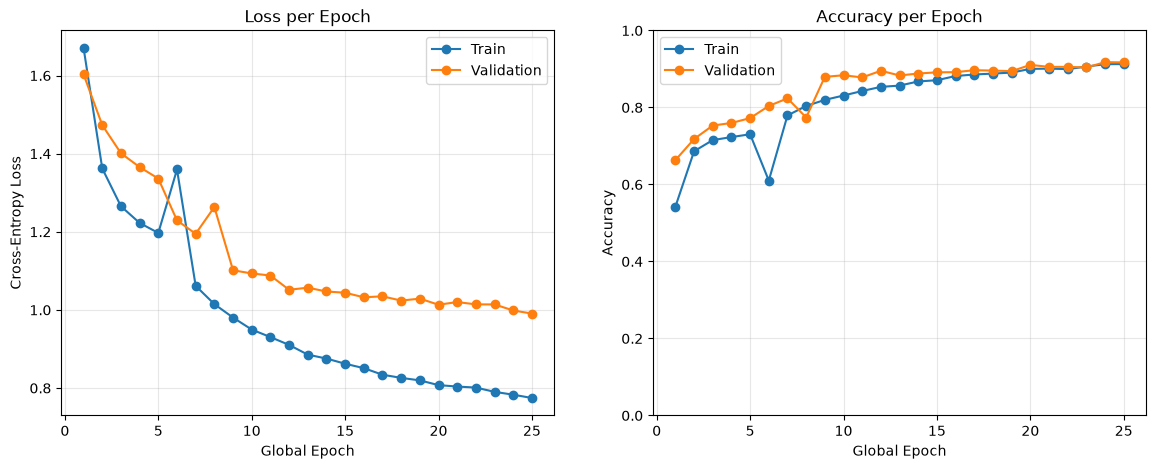

In [43]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)


axes[0].plot(
    history_df["global_epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train",
)

axes[0].plot(
    history_df["global_epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation",
)

axes[0].set_title(
    "Loss per Epoch"
)

axes[0].set_xlabel(
    "Global Epoch"
)

axes[0].set_ylabel(
    "Cross-Entropy Loss"
)

axes[0].grid(
    alpha=0.3
)

axes[0].legend()


axes[1].plot(
    history_df["global_epoch"],
    history_df["train_accuracy"],
    marker="o",
    label="Train",
)

axes[1].plot(
    history_df["global_epoch"],
    history_df["val_accuracy"],
    marker="o",
    label="Validation",
)

axes[1].set_title(
    "Accuracy per Epoch"
)

axes[1].set_xlabel(
    "Global Epoch"
)

axes[1].set_ylabel(
    "Accuracy"
)

axes[1].set_ylim(
    0.0,
    1.0,
)

axes[1].grid(
    alpha=0.3
)

axes[1].legend()

In [44]:
finetune_rows = history_df.loc[
    history_df["phase"].eq(
        "finetune_all"
    )
]


if not finetune_rows.empty:
    transition_epoch = (
        int(
            finetune_rows[
                "global_epoch"
            ].min()
        )
        - 0.5
    )


    for axis in axes:
        axis.axvline(
            transition_epoch,
            color="gray",
            linestyle="--",
            alpha=0.8,
        )


plt.tight_layout()


fig.savefig(
    CURVE_PATH,
    dpi=150,
    bbox_inches="tight",
)


plt.show()


print(
    "Kurva training disimpan pada:\n"
    f"{CURVE_PATH.relative_to(PROJECT_DIR)}"
)

<Figure size 640x480 with 0 Axes>

Kurva training disimpan pada:
logs\resnet18_20260825_233127\learning_curves.png


## Ringkasan Hasil per Fase

Ringkasan menampilkan jumlah epoch aktual serta performa terbaik dari setiap
fase training.

In [45]:
phase_summary = (
    history_df
    .groupby(
        "phase",
        as_index=False,
    )
    .agg(
        jumlah_epoch=(
            "phase_epoch",
            "count",
        ),
        train_loss_terakhir=(
            "train_loss",
            "last",
        ),
        val_loss_terbaik=(
            "val_loss",
            "min",
        ),
        train_accuracy_terbaik=(
            "train_accuracy",
            "max",
        ),
        val_accuracy_terbaik=(
            "val_accuracy",
            "max",
        ),
        waktu_total_detik=(
            "elapsed_seconds",
            "sum",
        ),
    )
)


display(
    phase_summary.round(6)
)

,phase,jumlah_epoch,train_loss_terakhir,val_loss_terbaik,train_accuracy_terbaik,val_accuracy_terbaik,waktu_total_detik
0,finetune_all,20,0.774526,0.990673,0.912751,0.917725,8983.434044
1,warmup_classifier,5,1.197074,1.336292,0.730505,0.772473,939.127521


## Pemeriksaan Generalization Gap

Generalization gap dihitung dari selisih training accuracy dan validation
accuracy.

Nilai positif yang besar dapat menunjukkan model mulai terlalu menyesuaikan
diri terhadap training dataset. Nilai ini hanya indikator awal dan harus
dibaca bersama kurva loss.

In [46]:
history_df["accuracy_gap"] = (
    history_df["train_accuracy"]
    - history_df["val_accuracy"]
)


history_df["loss_gap"] = (
    history_df["val_loss"]
    - history_df["train_loss"]
)


gap_table = history_df[
    [
        "phase",
        "global_epoch",
        "train_accuracy",
        "val_accuracy",
        "accuracy_gap",
        "train_loss",
        "val_loss",
        "loss_gap",
    ]
].copy()


display(
    gap_table.round(6)
)

,phase,global_epoch,train_accuracy,val_accuracy,accuracy_gap,train_loss,val_loss,loss_gap
0,warmup_classifier,1,0.542418,0.663281,-0.120863,1.670512,1.602953,-0.067559
1,warmup_classifier,2,0.686309,0.718131,-0.031822,1.362081,1.473058,0.110977
2,warmup_classifier,3,0.715392,0.753174,-0.037782,1.265343,1.401075,0.135732
3,warmup_classifier,4,0.723139,0.759777,-0.036637,1.222601,1.365569,0.142968
4,warmup_classifier,5,0.730505,0.772473,-0.041968,1.197074,1.336292,0.139218
5,finetune_all,6,0.610109,0.803961,-0.193852,1.359495,1.229197,-0.130298
6,finetune_all,7,0.779401,0.823768,-0.044368,1.061612,1.194897,0.133285
7,finetune_all,8,0.803912,0.773997,0.029915,1.014816,1.263398,0.248582
8,finetune_all,9,0.819787,0.879634,-0.059848,0.980457,1.101495,0.121037
9,finetune_all,10,0.831090,0.883697,-0.052608,0.949704,1.093404,0.143699


## Pemeriksaan Hasil Akhir

Pemeriksaan akhir memastikan:

- checkpoint terbaik tersedia;
- checkpoint terakhir tersedia;
- riwayat training tersimpan;
- konfigurasi training tersimpan;
- kurva pembelajaran tersimpan;
- metrik validation valid;
- test dataset tidak digunakan.

In [47]:
final_checks = {
    "Riwayat training tidak kosong": (
        not history_df.empty
    ),

    "Checkpoint terbaik tersedia": (
        BEST_CHECKPOINT_PATH.is_file()
    ),

    "Checkpoint terakhir tersedia": (
        LAST_CHECKPOINT_PATH.is_file()
    ),

    "Riwayat CSV tersedia": (
        HISTORY_PATH.is_file()
    ),

    "Konfigurasi training tersedia": (
        TRAINING_CONFIG_PATH.is_file()
    ),

    "Kurva training tersedia": (
        CURVE_PATH.is_file()
    ),

    "Validation loss finite": (
        np.isfinite(
            best_val_metrics["loss"]
        )
    ),

    "Validation accuracy valid": (
        0.0
        <= best_val_metrics["accuracy"]
        <= 1.0
    ),

    "Checkpoint tidak memakai test": (
        best_checkpoint.get(
            "test_data_used"
        )
        is False
    ),

    "Konfigurasi tidak memakai test": (
        training_config[
            "test_data_used"
        ]
        is False
    ),
}

In [48]:
final_check_table = pd.DataFrame({
    "Pemeriksaan": final_checks.keys(),
    "Status": [
        "Berhasil"
        if status
        else "Gagal"
        for status
        in final_checks.values()
    ],
})


display(final_check_table)


failed_checks = [
    check_name
    for check_name, status
    in final_checks.items()
    if not status
]


if failed_checks:
    formatted_checks = "\n".join(
        f"- {check_name}"
        for check_name
        in failed_checks
    )

    raise AssertionError(
        "Pemeriksaan akhir gagal:\n"
        f"{formatted_checks}"
    )


print(
    "Seluruh pemeriksaan akhir berhasil."
)

,Pemeriksaan,Status
0,Riwayat training tidak kosong,Berhasil
1,Checkpoint terbaik tersedia,Berhasil
2,Checkpoint terakhir tersedia,Berhasil
3,Riwayat CSV tersedia,Berhasil
4,Konfigurasi training tersedia,Berhasil
5,Kurva training tersedia,Berhasil
6,Validation loss finite,Berhasil
7,Validation accuracy valid,Berhasil
8,Checkpoint tidak memakai test,Berhasil
9,Konfigurasi tidak memakai test,Berhasil


Seluruh pemeriksaan akhir berhasil.


In [49]:
print("=" * 72)
print("TRAINING MODEL SELESAI")
print("=" * 72)

print(
    f"Model               : "
    f"{MODEL_NAME}"
)

print(
    f"Jumlah epoch aktual : "
    f"{len(history_df)}"
)

print(
    f"Fase terbaik        : "
    f"{best_checkpoint['phase']}"
)

print(
    f"Epoch terbaik       : "
    f"{best_checkpoint['global_epoch']}"
)

print(
    f"Validation loss     : "
    f"{best_val_metrics['loss']:.6f}"
)

print(
    f"Validation accuracy : "
    f"{best_val_metrics['accuracy']:.4%}"
)

print(
    f"Checkpoint terbaik  : "
    f"{BEST_CHECKPOINT_PATH.relative_to(PROJECT_DIR)}"
)

print(
    f"Checkpoint terakhir : "
    f"{LAST_CHECKPOINT_PATH.relative_to(PROJECT_DIR)}"
)

print(
    f"Riwayat training    : "
    f"{HISTORY_PATH.relative_to(PROJECT_DIR)}"
)

print(
    "Data test digunakan : Tidak"
)

print("=" * 72)

TRAINING MODEL SELESAI
Model               : resnet18
Jumlah epoch aktual : 25
Fase terbaik        : finetune_all
Epoch terbaik       : 25
Validation loss     : 0.990673
Validation accuracy : 91.7217%
Checkpoint terbaik  : models\resnet18_gcd_best.pth
Checkpoint terakhir : models\resnet18_gcd_last.pth
Riwayat training    : logs\resnet18_20260825_233127\training_history.csv
Data test digunakan : Tidak


## Menjalankan TensorBoard

Jalankan perintah berikut melalui terminal VS Code dari folder utama project.

```powershell
.\.venv\Scripts\python.exe -m tensorboard --logdir logs


---

# BAGIAN 36 — Kesimpulan Notebook

Buat sel **Markdown**:

```markdown
## Kesimpulan

Tahap training model klasifikasi jenis awan telah selesai.

Hasil utama:

1. Konfigurasi DataLoader dibaca dari `dataloader_config.json`.
2. Arsitektur model dibaca dari `model_config.json`.
3. Transform training dan validation dimuat dari file JSON notebook 05.
4. Dataset dibentuk menggunakan ImageFolder tanpa memindai ulang dataset mentah.
5. Pemetaan label disesuaikan dengan class mapping tahap sebelumnya.
6. Bobot kelas dihitung hanya dari training split.
7. Fase warm-up melatih classifier dengan backbone dibekukan.
8. Fase fine-tuning melatih seluruh parameter dengan learning rate lebih kecil.
9. Validation loss digunakan untuk menentukan checkpoint terbaik.
10. Early stopping diterapkan secara terpisah pada setiap fase.
11. Checkpoint terbaik dan checkpoint terakhir berhasil disimpan.
12. Riwayat training, konfigurasi, TensorBoard, dan kurva pembelajaran disimpan.
13. Test dataset tidak digunakan dalam training maupun pemilihan model.

File yang dihasilkan:

- `models/resnet18_gcd_best.pth`
- `models/resnet18_gcd_last.pth`
- `logs/resnet18_<waktu>/training_history.csv`
- `logs/resnet18_<waktu>/training_config.json`
- `logs/resnet18_<waktu>/learning_curves.png`
- `logs/resnet18_<waktu>/tensorboard/`

Tahap berikutnya adalah membuat `09_evaluasi_model.ipynb`.

Pada tahap evaluasi, checkpoint terbaik dimuat dan test split digunakan satu
kali untuk menghitung:

- test loss;
- test accuracy;
- precision;
- recall;
- F1-score;
- confusion matrix;
- classification report;
- prediksi benar dan prediksi salah.